In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn

In [6]:
# some tidying of the data 

books = pd.read_csv('../../../data/data_with_author_and_awards.csv')

# apply data cleaning stuff 

%run ../../../data/tidy_book_tags.ipynb # to get clean_filter_tags function

%run ../../../data/tidy_publisher.ipynb # to get publisher_tidy function

books['first_publisher'] = publisher_tidy(books['first_publisher'])

books['tags'] = clean_filter_tags(books['tags'])

# combine awards into one target column

books['target'] = books['hugo'] | books['locus']

/var/folders/bt/8s6v7ngs6m93f2x58bpj1zl00000gn/T/ipykernel_45111/2975507185.py:3: DtypeWarning: Columns (0: isbn) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../../../data/data_with_author_and_awards.csv')


In [7]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,target
0,9372.0,The Long Loud Silence,Wilson Tucker,1954,1954-00-00,dell,1914.0,"Deer Creek, Illinois, USA",0899683754,Publisher's description: Tomorrow's war -- the...,...,False,Unknown,40,0,0,False,False,USA,Central/North America,False
1,2215181.0,Mrs. Candy Strikes It Rich,Robert Tallant,1954,1954-00-00,doubleday,1909.0,"New Orleans, Louisiana, USA",NaN,NaN,...,False,Unknown,45,0,0,False,False,USA,Central/North America,False
2,1392436.0,Return to the Lost Planet,Angus MacVicar,1954,1954-00-00,burke,1908.0,"Duror, Argyll, Scotland, UK",NaN,NaN,...,False,Unknown,46,0,0,False,False,UK,Europe,False
3,1112206.0,Rainbow on the Road,Esther Forbes,1954,1954-00-00,houghtonmifflin,1891.0,"Westborough, Massachusetts, USA",NaN,NaN,...,False,Unknown,63,0,0,False,False,USA,Central/North America,False
4,1908.0,The Forgotten Planet,Murray Leinster,1954,1954-00-00,ace,1896.0,"Norfolk, Virginia, USA",0881846163,"**From the first page of the Ace Double:** ""Na...",...,False,Unknown,58,0,0,False,False,USA,Central/North America,False


In [8]:
# do not want books from before awards
books = books[books['release_year'] >= 1970]

In [9]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,target
4100,689509.0,The Simultaneous Man,Ralph Blum,1970,1970-03-00,bantambooks,1932.0,"Los Angeles, California, USA",0553058789,NaN,...,False,03,38,0,0,False,False,USA,Central/North America,False
4101,2297062.0,The Three Straw Men,August Derleth,1970,1970-11-00,candlelightpress,1909.0,"Sauk City, Wisconsin, USA",0876860080,NaN,...,False,11,61,0,0,False,False,USA,Central/North America,False
4102,2499270.0,Witch's Suckling,Gimone Hall,1970,1970-09-00,manorbooks,NaN,NaN,NaN,NaN,...,False,09,Unknown,0,0,False,False,Unknown,Unknown,False
4103,531585.0,The Sorcerer's Skull,David Mason,1970,1970-00-00,lancerbooks,1924.0,NaN,1587150638,NaN,...,False,Unknown,46,0,0,False,False,Unknown,Unknown,False
4104,1984860.0,Bantan and the Mermaids,Maurice B. Gardner,1970,1970-00-00,theo.gaus'sons,1905.0,"Portland, Maine, USA",NaN,NaN,...,False,Unknown,65,0,0,False,False,USA,Central/North America,False


In [10]:
# MISSINGNESS:
# for the sake of this notebook, we shall:
# - omit book synopses, title_id, isbn, release_date (captured in month), author_birthyear, author_birthplace (captured in country and continent)
# - and turn all empty tags into empty string ""

books = books.drop(["title_id", "isbn", "release_date", "author_birthyear", "book_synopsis", "author_birthplace"], axis=1)


In [1176]:
books['tags'] = books['tags'].apply(lambda x: '' if isinstance(x, float) else x)

In [1177]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   title                        147491 non-null  str   
 1   author                       147491 non-null  str   
 2   release_year                 147491 non-null  int64 
 3   first_publisher              147491 non-null  str   
 4   tags                         147491 non-null  object
 5   hugo                         147491 non-null  bool  
 6   locus                        147491 non-null  bool  
 7   month_of_publication         147449 non-null  str   
 8   Author_Age_at_Publication    147491 non-null  str   
 9   Hugo_Awards_Previously       147491 non-null  int64 
 10  Locus_Awards_Previously      147491 non-null  int64 
 11  Hugo_Nominee_Before          147491 non-null  bool  
 12  Locus_Nominee_Before         147491 non-null  bool  
 13  author_birthplace_coun

In [ ]:
books['Author_Age_at_Publication'] = pd.to_numeric(
    books['Author_Age_at_Publication'], errors='coerce'
)




In [1809]:
books_tt = books[(books['release_year'] >= 1971) & (books['release_year'] < 2015)]

books_test = books[(books['release_year'] >= 2015)]


In [1810]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   title                        147491 non-null  str    
 1   author                       147491 non-null  str    
 2   release_year                 147491 non-null  int64  
 3   first_publisher              147491 non-null  str    
 4   tags                         147491 non-null  object 
 5   hugo                         147491 non-null  bool   
 6   locus                        147491 non-null  bool   
 7   month_of_publication         147449 non-null  str    
 8   Author_Age_at_Publication    66188 non-null   float64
 9   Hugo_Awards_Previously       147491 non-null  int64  
 10  Locus_Awards_Previously      147491 non-null  int64  
 11  Hugo_Nominee_Before          147491 non-null  bool   
 12  Locus_Nominee_Before         147491 non-null  bool   
 13  author_

##### Preprocessing of columns

In [1811]:
#  0   title                        147491 non-null  str   -- not used
#  1   author                       147491 non-null  str   -- not used
#  2   release_year                 147491 non-null  int64 -- used (for normalization per yar)
#  3   first_publisher              147491 non-null  str   -- use (catergorical)
#  4   tags                         147491 non-null  object -- use (multilabel binarize)
#  5   hugo                         147491 non-null  bool  -- not used (use combine target)
#  6   locus                        147491 non-null  bool  -- not used (use combine target)
#  7   month_of_publication         147449 non-null  str   -- use (categorical)
#  8   Author_Age_at_Publication    147491 non-null  int64   -- use (numerical)
#  9   Hugo_Awards_Previously       147491 non-null  int64 -- use (numerical)
#  10  Locus_Awards_Previously      147491 non-null  int64 -- use (numerical)
#  11  Hugo_Nominee_Before          147491 non-null  bool  -- use (numerical)
#  12  Locus_Nominee_Before         147491 non-null  bool  -- use (numerical)
#  13  author_birthplace_country    147491 non-null  str   -- use (categorical) 
#  14  author_birthplace_continent  147491 non-null  str   -- use (categorical)
#  15  target                       147491 non-null  bool  -- target (categorical or numerical)

In [1812]:
books_tt['Total_Awards_Previously'] = books_tt['Hugo_Awards_Previously'] + books_tt['Locus_Awards_Previously']
books_tt['NomineeBefore'] = books_tt['Hugo_Nominee_Before'] | books_tt['Locus_Nominee_Before']

In [1813]:
#we also want to add some more author features:

# how many books author has published to date, including this book
books_tt['author_num_books'] = books_tt.groupby('author').cumcount()
books_tt['new_author'] = (books_tt['author_num_books'] == 1)

# how long since this author was last nominated (if none, set to 100)

books_tt['nomination_years'] = books_tt['release_year'].where(books_tt['target'] == 1)
books_tt['last_nomination_year'] = books_tt.groupby('author')['nomination_years'].ffill().groupby(books_tt['author']).shift(1)
books_tt['years_since_last_nomination'] = books_tt['release_year'] - books_tt['last_nomination_year']
books_tt['years_since_last_nomination'] = books_tt['years_since_last_nomination'].fillna(np.nan)

books_tt.drop(columns=['nomination_years', 'last_nomination_year'], inplace=True)

# how many nominees has this publisher had in the past?
books_tt['publisher_historical_nominations'] = books_tt.groupby('first_publisher')['target'].cumsum() - books['target']
books_tt['publisher_cohort_size'] = books_tt.groupby(['release_year', 'first_publisher'])['title'].transform('count')

books_tt['debut_publisher_importance'] = books_tt['new_author'] * books_tt['publisher_historical_nominations']


In [1814]:
books['first_publisher'] = combine_publishers(books['first_publisher'], limitnum=300)


In [1815]:
numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size", 'debut_publisher_importance']
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

In [1816]:
for col in numerical_features:
    books_tt[col] = books_tt[col].astype(float)

In [1817]:
books['first_publisher'].value_counts(normalize=True)

first_publisher
Other              0.744615
tor                0.022225
ace                0.014631
lmbpnpublishing    0.009079
createspace        0.009004
                     ...   
avonbooks          0.002231
simonpulse         0.002224
alfreda.knopf      0.002204
iuniverse          0.002176
angryrobot         0.002170
Name: proportion, Length: 61, dtype: float64

In [1818]:
## do multilabel binarizer of tags outside preprocessing. 
from sklearn.preprocessing import MultiLabelBinarizer

tag_labeler = MultiLabelBinarizer()
tag_labels = tag_labeler.fit_transform(books_tt['tags'].fillna(''))

# save as dataframe
tag_dataframe = pd.DataFrame(
    tag_labels,
    columns = ["tag_{}".format(tag) for tag in tag_labeler.classes_],
    index=books_tt.index
)

# concatenate to training dataframe
books_tt = pd.concat([books_tt, tag_dataframe], axis=1)

In [1819]:
# calculate dot product with other books' genre tags
from sklearn.metrics.pairwise import cosine_similarity

def get_similarity_list(df):
    for year, data in df.groupby('release_year'):
        tag_data = data[list(tag_dataframe.columns)]
        similarity = cosine_similarity(tag_data)
        np.fill_diagonal(similarity, np.nan)
        book_mean_similarity = np.nanmean(similarity, axis=0)
    return book_mean_similarity

In [1820]:
books_tt['NomineeBefore'].value_counts()

NomineeBefore
False    69995
True      5113
Name: count, dtype: int64

In [1821]:
books_tt['new_author'].value_counts()

new_author
False    64244
True     10864
Name: count, dtype: int64

In [1822]:
books_tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 75108 entries, 4548 to 79655
Columns: 142 entries, title to tag_zombi
dtypes: bool(7), float64(7), int64(121), object(1), str(6)
memory usage: 82.1+ MB


for some features, we want to normalize against the rest of the cohort.

for numerical features, this is z-score normalization, through StandardScaler().

but, we want to normalize within each year, not across all years.

let's try to build a custom transformer with guidance from https://www.andrewvillazon.com/custom-scikit-learn-transformers/


In [ ]:
from numpy.random import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

class YearByYearStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', scale_columns=None):
        self.scale_columns = scale_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # apply standard scaler to each year group by group
        for year, data in X.groupby(by=self.year_column):
            imputer = SimpleImputer(strategy='mean')
            X.loc[data.index, self.scale_columns] = imputer.fit_transform(data[self.scale_columns])

            scaler = StandardScaler()

            X.loc[data.index, self.scale_columns] = scaler.fit_transform(data[self.scale_columns])#pd.DataFrame(scaler.fit_transform(data[self.scale_columns]))

        return X.drop(columns=[self.year_column])
    
    def get_feature_names_out(self, input_features=None):
            if input_features is None:
                raise ValueError("input_features must be provided to get names.")
            input_features = np.asarray(input_features, dtype=object)

            return input_features[input_features != self.year_column]
    
class YearlyGenreTagScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', tag_columns=None):
        self.tag_columns = tag_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()

        similarity_series = pd.Series(dtype=float, index=X.index)

        for year, data in X.groupby(by=self.year_column):
            tag_data = data[self.tag_columns]
            similarity = cosine_similarity(tag_data)
            book_mean_similarity = np.mean(similarity, axis=0)
            similarity_series.loc[data.index] = book_mean_similarity

        X['cohort_similiarity'] = similarity_series
        return X.drop(columns=self.tag_columns+ [self.year_column])
    
    def get_feature_names_out(self, input_features=None):
            if input_features is None:
                raise ValueError("input_features must be provided to get names.")
            

            return np.array(['cohort_similiarity'], dtype=object)
    

class YearlyPastWinnerSimilarityScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='release_year', tag_columns=None):
        self.tag_columns = tag_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("This transformer requires a target array `y` to identify historical winners.")
            
        temp_df = X.copy()
        temp_df['is_winner'] = y
        

        self.winner_lookup_ = {}
        for year, group in temp_df[temp_df['is_winner'] == 1].groupby(self.year_column):
            self.winner_lookup_[year] = group[self.tag_columns].values
            
        return self

    def transform(self, X, y=None):
        X = X.copy()
        past_winner_sim_series = pd.Series(dtype=float, index=X.index)
        
        for current_year, data in X.groupby(by=self.year_column):
            past_vectors = [v for yr, v in self.winner_lookup_.items() if yr < current_year]
            
            if not past_vectors:
                past_winner_sim_series.loc[data.index] = 0.0
                continue
                
            past_winners_matrix = np.vstack(past_vectors)
            current_matrix = data[self.tag_columns].values
            
            sim_matrix = cosine_similarity(current_matrix, past_winners_matrix)
            past_winner_sim_series.loc[data.index] = np.mean(sim_matrix, axis=1)

        X['past_winner_similarity'] = past_winner_sim_series
        return X.drop(columns=self.tag_columns + [self.year_column])
    

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            raise ValueError("input_features must be provided to get names.")
        
        # CONCRETELY: This step drops all tag columns and the year column, 
        # and outputs EXACTLY one brand new column name.
        return np.array(['past_winner_similarity'], dtype=object)


In [1824]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

tags_pipeline = Pipeline(
    steps=[
        ('similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'))
    ]
)

feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('bool_to_int', FunctionTransformer(lambda x: x.astype(int), feature_names_out='one-to-one'), bool_features),
        ('onehot', categorical_pipeline, categorical_features),
    ('tag_similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year']) ,
    ('nominee_similarity', YearlyPastWinnerSimilarityScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'), list(tag_dataframe.columns) + ['release_year'])    ],
    # remainder='passthrough'
)



In [1825]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
import xgboost as xgb
from sklearn.metrics import average_precision_score, ndcg_score

xgb_model =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@100",             # This forces evaluation on the top 50
    # FIX: Remove lambdarank_topk and use the correct parameter for the pair method:
    lambdarank_pair_method="topk",
    # In newer XGBoost versions, top-k pairs are managed via lambdarank_num_pair_per_sample
    lambdarank_num_pair_per_sample=512, 
    
    # max_depth=5,                       
    # learning_rate=0.05,
    # n_estimators=500,                  
    # colsample_bytree=0.7,              
    # subsample=0.8


    
))
])

param_grid = {
    'xgb_rank__objective': ['rank:pairwise', 'rank:ndcg', 'rank:map'],
    'xgb_rank__max_depth': [3, 5, 7],
    'xgb_rank__learning_rate': [0.01, 0.05, 0.1],
    'xgb_rank__n_estimators': [100, 300, 500],
    # 'xgb_rank__colsample_bytree': [0.5, 0.7, 0.8],
    # 'xgb_rank__subsample': [0.8, 0.9, 0.7],

}


In [1826]:
# Walk-Forward Validation: re-train on increasingly larger training set

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - initial_size - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits

windows = walk_forward(books_tt)


In [ ]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal', 'black']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

fig = plt.figure()

confusion_matrices = {}

name = 'xgb_rank'
model = xgb_model

mean_score = 0
f1scores = []
praucs = []
ndgs = []
confs = np.zeros((2,2))
pooled_ypreds = []
pooled_true = []
number_true = []

val_years = []

cvgrid_values = []

from sklearn.model_selection import ParameterGrid

for num, fold in enumerate(windows):
    book_train = fold[0]
    book_val = fold[1]


    for params in ParameterGrid(param_grid):
        # Update the model with current grid parameters
        model.set_params(xgb_rank__learning_rate=params['xgb_rank__learning_rate'], 
                        xgb_rank__max_depth=params['xgb_rank__max_depth'],
                        xgb_rank__objective=params['xgb_rank__objective'],
                        xgb_rank__n_estimators=params['xgb_rank__n_estimators'])


        model.fit(book_train[features], book_train['target'], xgb_rank__qid=book_train['release_year'])

        

        num_finalists = 60#int(book_val['target'].sum())

        ypred = model.predict(book_val[features])
        book_val['predicted_score'] = ypred

        book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )

        book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

        val_years.append(book_val['release_year'].mode())

        ypred_binary = book_val['predicted'].values

        if num != len(windows) - 1:
            book_val.drop(columns=['predicted_score', 'rank_within_year', 'predicted'], inplace=True)    
            
        f1score = f1_score(book_val['target'], ypred_binary)

        conf = confusion_matrix(book_val['target'], ypred_binary, normalize='true')

        tn, fp, fn, tp = conf.ravel()
        recall = tp / (tp + fn)


        cvgrid_values.append([num, params['xgb_rank__learning_rate'], params['xgb_rank__max_depth'],params['xgb_rank__n_estimators'], params['xgb_rank__objective'], f1score, recall, conf])


    pooled_true.extend(book_val['target'])
    pooled_ypreds.extend(ypred_binary)


    conf = confusion_matrix(book_val['target'], ypred_binary, normalize='true')#.ravel().tolist()
    confs += conf / len(windows)

    mean_score += f1score / len(windows)



print("Mean f1-score: {}; Max: {}; Min: {}".format(mean_score, max(f1scores), min(f1scores)))
print("Pooled f1-score:", f1_score(pooled_true, pooled_ypreds))

confusion_matrices[name] = confs


plt.plot(val_years, f1scores, label = "f1")
plt.axhline(mean_score, linestyle='dashed')
plt.plot(val_years, praucs, label = "praucs")

fig.legend(loc="upper center", ncol = 2)
plt.title("nested time CV, Walk-Forward Validation with step of 1")


In [ ]:
cvgrid = pd.DataFrame(cvgrid_values, columns = ["num", 'xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective', 'f1score', 'recall', 'conf'])


In [1566]:
cvgrid

,num,xgb_rank__colsample_bytree,xgb_rank__subsample,f1score,conf
0,0,0.5,0.8,0.444444,"[[0.9290540540540541, 0.07094594594594594], [0..."
1,0,0.5,0.9,0.444444,"[[0.9290540540540541, 0.07094594594594594], [0..."
2,0,0.5,0.7,0.444444,"[[0.9290540540540541, 0.07094594594594594], [0..."
3,0,0.7,0.8,0.444444,"[[0.9290540540540541, 0.07094594594594594], [0..."
4,0,0.7,0.9,0.444444,"[[0.9290540540540541, 0.07094594594594594], [0..."
...,...,...,...,...,...
204,22,0.8,0.8,0.574074,"[[0.9759136212624585, 0.02408637873754153], [0..."
205,22,0.8,0.9,0.555556,"[[0.9750830564784053, 0.024916943521594685], [..."
206,22,0.8,0.7,0.592593,"[[0.9767441860465116, 0.023255813953488372], [..."
207,23,0.5,0.8,0.568627,"[[0.9763177998472116, 0.023682200152788387], [..."


In [1589]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['f1score'].mean()

# mean_f1s = cvgrid.groupby(['xgb_rank__colsample_bytree', 'xgb_rank__subsample', 'f1score', 'conf'])['f1score'].mean()

# ["num", 'xgb_rank__colsample_bytree', 'xgb_rank__subsample', 'f1score', 'conf']

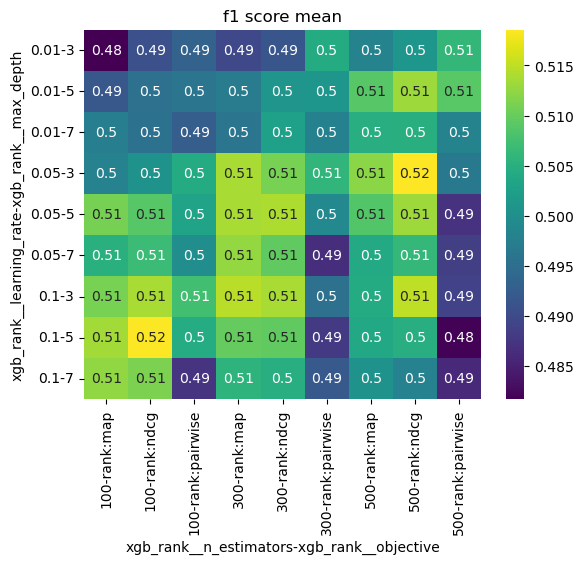

In [ ]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['f1score'].mean()

mean_f1s_df = mean_f1s.reset_index(name='mean_f1_score')
mean_f1s_df.sort_values(by='mean_f1_score', ascending=False).head(5)

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = mean_f1s_df.pivot_table(
    values='mean_f1_score', 
    index=['xgb_rank__learning_rate', 'xgb_rank__max_depth'], 
    columns=['xgb_rank__n_estimators','xgb_rank__objective']
)

sns.heatmap(pivot_df, annot=True, cmap='viridis')
plt.title("f1 score mean")
plt.show()


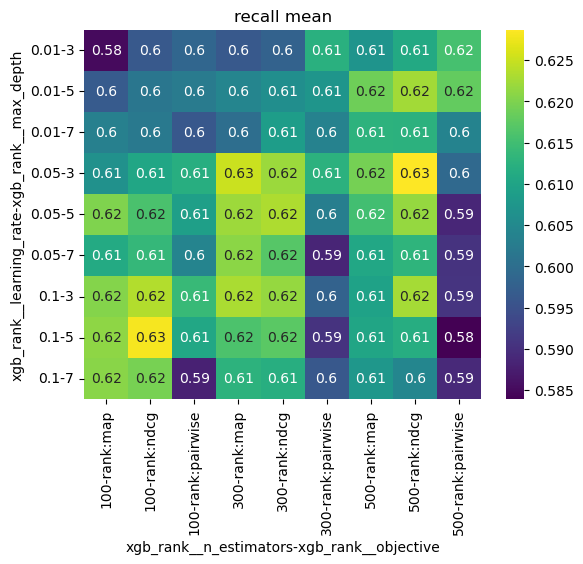

In [ ]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['recall'].mean()

mean_f1s_df = mean_f1s.reset_index(name='mean_f1_score')
mean_f1s_df.sort_values(by='mean_f1_score', ascending=False).head(5)

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = mean_f1s_df.pivot_table(
    values='mean_f1_score', 
    index=['xgb_rank__learning_rate', 'xgb_rank__max_depth'], 
    columns=['xgb_rank__n_estimators','xgb_rank__objective']
)
plt.title("recall mean")

sns.heatmap(pivot_df, annot=True, cmap='viridis')
plt.show()

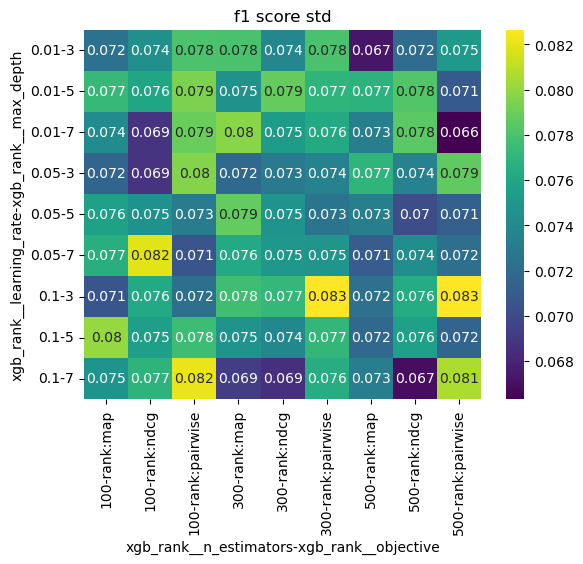

In [ ]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['f1score'].std()

mean_f1s_df = mean_f1s.reset_index(name='mean_f1_score')
mean_f1s_df.sort_values(by='mean_f1_score', ascending=False).head(5)

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = mean_f1s_df.pivot_table(
    values='mean_f1_score', 
    index=['xgb_rank__learning_rate', 'xgb_rank__max_depth'], 
    columns=['xgb_rank__n_estimators','xgb_rank__objective']
)

sns.heatmap(pivot_df, annot=True, cmap='viridis')
plt.title("f1 score std")
plt.show()

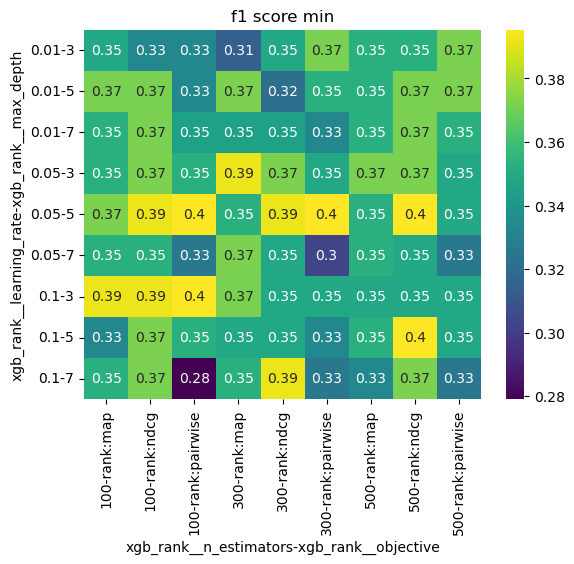

In [ ]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['f1score'].min()

mean_f1s_df = mean_f1s.reset_index(name='mean_f1_score')
mean_f1s_df.sort_values(by='mean_f1_score', ascending=False).head(5)

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = mean_f1s_df.pivot_table(
    values='mean_f1_score', 
    index=['xgb_rank__learning_rate', 'xgb_rank__max_depth'], 
    columns=['xgb_rank__n_estimators','xgb_rank__objective']
)

sns.heatmap(pivot_df, annot=True, cmap='viridis')
plt.title("f1 score min")
plt.show()

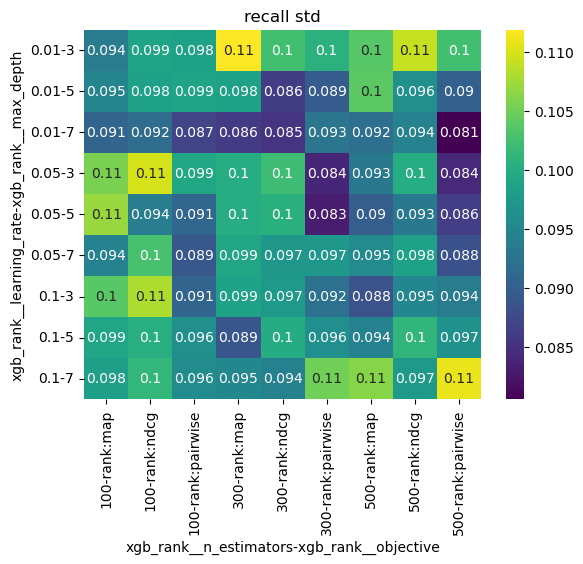

In [ ]:
mean_f1s = cvgrid.groupby(['xgb_rank__learning_rate', 'xgb_rank__max_depth', 'xgb_rank__n_estimators','xgb_rank__objective'])['recall'].std()

mean_f1s_df = mean_f1s.reset_index(name='mean_f1_score')
mean_f1s_df.sort_values(by='mean_f1_score', ascending=False).head(5)

import seaborn as sns
import matplotlib.pyplot as plt

pivot_df = mean_f1s_df.pivot_table(
    values='mean_f1_score', 
    index=['xgb_rank__learning_rate', 'xgb_rank__max_depth'], 
    columns=['xgb_rank__n_estimators','xgb_rank__objective']
)

sns.heatmap(pivot_df, annot=True, cmap='viridis')
plt.title("recall std")
plt.show()

Based on this, we keep the following two models:

learning rate: 0.1, max_depth=5, n_estimators=100, rank:ndcg
learning rate: 0.05, max_depth=5, n_estimators=500, rank:ndcg

In [ ]:
xgb_model1 =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@50",             
    lambdarank_pair_method="topk",
    lambdarank_num_pair_per_sample=512, 
    
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=500,                  
    colsample_bytree=0.7,              
    subsample=0.8
))
])

xgb_model2 =  Pipeline(steps=[
        ('preprocess', feature_preprocessing),
        ('xgb_rank', xgb.XGBRanker(
    tree_method="hist",
    objective="rank:ndcg",
    eval_metric="ndcg@100",             
    lambdarank_pair_method="topk",
    lambdarank_num_pair_per_sample=512, 
    
    max_depth=5,                       
    learning_rate=0.05,
    n_estimators=500,                  
    colsample_bytree=0.7,              
    subsample=0.8
    ))
])

models = {
    'model1': xgb_model1#, 
    # 'model2': xgb_model2
}

In [1854]:
books_tt['is_debut_nominee'] = ~books_tt['NomineeBefore']

windows = walk_forward(books_tt)


Mean f1-score: 0.5190174963788622; Max: 0.6981132075471698; Min: 0.37209302325581395
Pooled f1-score: 0.5202741290691034
Mean debut recall: 0.09816646972788842
Mean non-debut recall: 0.8162065345343358


Text(0.5, 1.0, 'nested time CV, Walk-Forward Validation with step of 1')

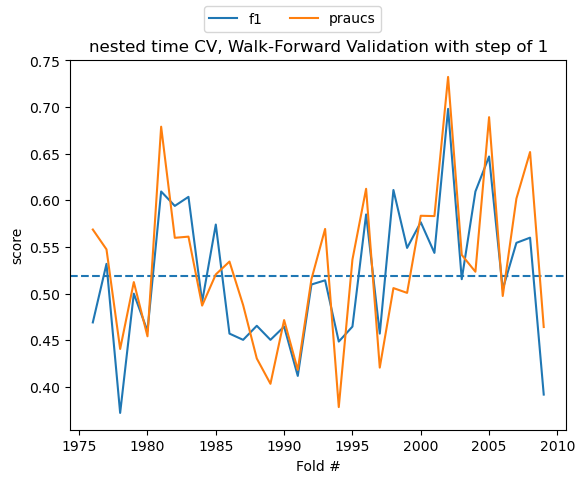

In [ ]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal', 'black']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

fig = plt.figure()

confusion_matrices = {}


cvgrid_values = []

from sklearn.model_selection import ParameterGrid

for name, model in models.items():

    mean_score = 0
    f1scores = []
    praucs = []
    ndgs = []
    confs = np.zeros((2,2))
    pooled_ypreds = []
    pooled_true = []
    number_true = []

    overall_recalls = []
    debut_recalls = []
    non_debut_recalls = []

    val_years = []


    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]

        book_train = book_train.sort_values('release_year').reset_index(drop=True)


        model.fit(
            book_train[features],
            book_train['target'],
            xgb_rank__qid=book_train['release_year'],
        )


        

        num_finalists = 60#int(book_val['target'].sum())

        ypred = model.predict(book_val[features])
        book_val['predicted_score'] = ypred

        book_val['rank_within_year'] = book_val.groupby('release_year')['predicted_score'].rank(
            method='first', 
            ascending=False
        )

        book_val['predicted'] = (book_val['rank_within_year'] <= num_finalists).astype(int)

        val_years.append(book_val['release_year'].mode())

        ypred_binary = book_val['predicted'].values

        if num != len(windows) - 1:
            book_val.drop(columns=['predicted_score', 'rank_within_year', 'predicted'], inplace=True)    
            


        from sklearn.metrics import recall_score

        f1score = f1_score(book_val['target'], ypred_binary)

        overall_recall = recall_score(book_val['target'], ypred_binary)  # this one's already fine, no column lookup


        debut_mask = book_val['is_debut_nominee'] == 1
        debut_true_positives = book_val.loc[debut_mask, 'target'].sum()

        if debut_true_positives > 0:
            debut_recall = recall_score(
                book_val.loc[debut_mask, 'target'],
                ypred_binary[debut_mask.values]  
            )
        else:
            debut_recall = np.nan

        non_debut_mask = ~debut_mask
        non_debut_true_positives = book_val.loc[non_debut_mask, 'target'].sum()

        if non_debut_true_positives > 0:
            non_debut_recall = recall_score(
                book_val.loc[non_debut_mask, 'target'],
                ypred_binary[non_debut_mask.values]
            )
        else:
            non_debut_recall = np.nan



        f1score = f1_score(book_val['target'], ypred_binary)
        pr_auc = average_precision_score(book_val['target'], ypred)



        conf = confusion_matrix(book_val['target'], ypred_binary, normalize='true')

        tn, fp, fn, tp = conf.ravel()
        recall = tp / (tp + fn)


        f1scores.append(f1score)
        praucs.append(pr_auc)


        overall_recalls.append(overall_recall)
        debut_recalls.append(debut_recall)
        non_debut_recalls.append(non_debut_recall)

        pooled_true.extend(book_val['target'])
        pooled_ypreds.extend(ypred_binary)


        conf = confusion_matrix(book_val['target'], ypred_binary, normalize='true')#.ravel().tolist()
        confs += conf / len(windows)


        mean_score += f1score / len(windows)


    print("Mean f1-score: {}; Max: {}; Min: {}".format(mean_score, max(f1scores), min(f1scores)))
    print("Pooled f1-score:", f1_score(pooled_true, pooled_ypreds))

    confusion_matrices[name] = confs

    print("Mean debut recall:", np.nanmean(debut_recalls))
    print("Mean non-debut recall:", np.nanmean(non_debut_recalls))

plt.plot(val_years, f1scores, label = "f1")
plt.axhline(mean_score, linestyle='dashed')
plt.plot(val_years, praucs, label = "praucs")


plt.xlabel("Fold #")
plt.ylabel("score")

fig.legend(loc="upper center", ncol = 2)
plt.title("nested time CV, Walk-Forward Validation with step of 1")


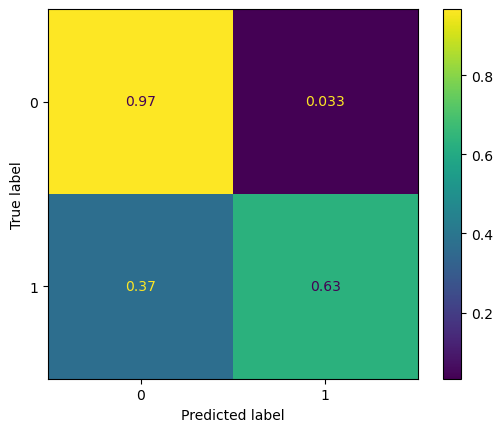

In [1857]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=confusion_matrices['model1']).plot()


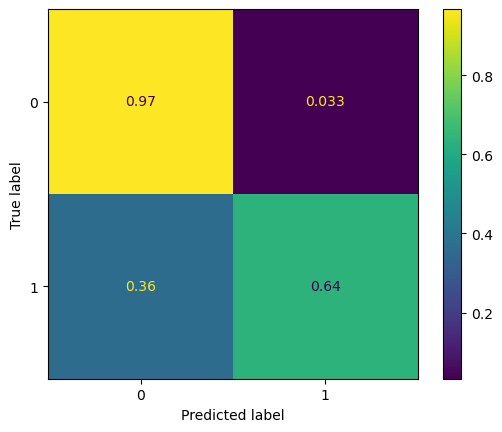

In [1687]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(confusion_matrix=confusion_matrices['model1']).plot()


In [ ]:
feature_names = xgb_model1.named_steps['preprocess'].get_feature_names_out()

importances = xgb_model1.named_steps['xgb_rank'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Gain)': importances
}).sort_values(by='Importance (Gain)', ascending=False)

print(importance_df.head(20))

                                              Feature  Importance (Gain)
0          numerical_scaling__Total_Awards_Previously           0.267105
15            onehot__first_publisher_ballantinebooks           0.149234
28                  onehot__first_publisher_doubleday           0.058847
76         nominee_similarity__past_winner_similarity           0.052326
58                        onehot__first_publisher_tor           0.049600
75                 tag_similarity__cohort_similiarity           0.049348
17              onehot__first_publisher_bantamspectra           0.032854
27                     onehot__first_publisher_delrey           0.030669
1                 numerical_scaling__author_num_books           0.028519
30                   onehot__first_publisher_gollancz           0.025941
74               onehot__month_of_publication_Unknown           0.023893
2   numerical_scaling__publisher_historical_nomina...           0.019786
6                       onehot__first_publisher_Oth

In [ ]:
importance_df[importance_df['Feature'] == 'one']

what are the books that the ranker is missing? Are they the new releases?

In [1618]:
book_val['predicted'] = ypred_binary

missed_books = book_val[(book_val['predicted'] == 0) & (book_val['target'] == 1)]
identified_books = book_val[(book_val['predicted'] == 1) & (book_val['target'] == 1)]
misidentified = book_val[(book_val['predicted'] == 1) & (book_val['target'] == 0)]

In [ ]:
missed_books['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0    12
3.0     3
6.0     1
Name: count, dtype: int64

In [ ]:
misidentified['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
0.0     7
3.0     6
2.0     6
9.0     5
1.0     3
11.0    2
5.0     2
6.0     2
8.0     2
26.0    1
10.0    1
4.0     1
21.0    1
Name: count, dtype: int64

In [ ]:
identified_books['Total_Awards_Previously'].value_counts()

Total_Awards_Previously
16.0    3
1.0     3
2.0     2
8.0     2
3.0     2
12.0    2
6.0     1
9.0     1
11.0    1
17.0    1
13.0    1
4.0     1
26.0    1
Name: count, dtype: int64

The missed books are more likely to have never won an award before.

In [ ]:
missed_books['new_author'].value_counts()

new_author
False    12
True      4
Name: count, dtype: int64

In [ ]:
identified_books['new_author'].value_counts()

new_author
False    20
True      1
Name: count, dtype: int64

In [ ]:
misidentified['new_author'].value_counts()

new_author
False    36
True      3
Name: count, dtype: int64

Let's see whether these missed books are ranked close to the threshold, or very low.

<Axes: >

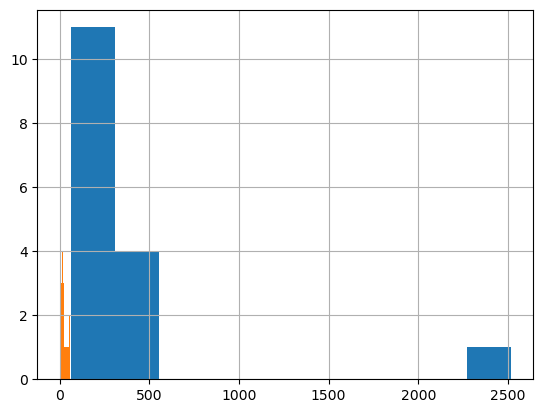

In [ ]:
missed_books['rank_within_year'].hist()
identified_books['rank_within_year'].hist()

They are ranked with a large spread, so the model is not close to pushing these to the top.